In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from abm_event import sample_event, conditional_sample
from abm_ll import city_ll, eval_ds
from stat_utils import CityParams, EventOutcome, GeneralParams, logrange
from param_distr import ParamDistr, param_config
from city_data import subsampled_city_data, subsample_weights
from stat_utils import grenander_pdf
param_distr = ParamDistr(param_config)

import os
import numpy as np
import scipy.stats as scs
# x0 = np.array(param_distr.sample_range(jrand.PRNGKey(2)))

In [2]:
x0 = np.array([-7.49712599, 5,  2, 1.5, -5.42167238])
params = param_distr.transform_sample(x0)
params = GeneralParams(*np.array(params))
rng_key = jrand.PRNGKey(0)

distr_l = []
for c in subsampled_city_data[::10]:
    c_params = c['params']
    c_events = c['events']
    rng_key, subkey = jrand.split(rng_key, 2)
    event_sim = conditional_sample(c_params, params, subkey, num_samples=100000)
    city_distr = grenander_pdf(event_sim+1)
    distr_l.append(city_distr)

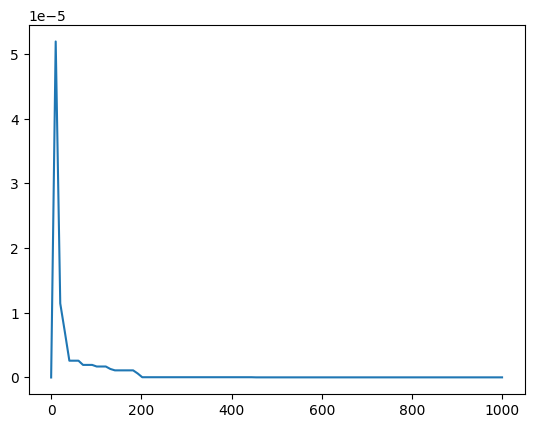

In [3]:
s = np.linspace(0, 1000, 100)
for i, city_distr in enumerate(distr_l[2:3]):
    plt.plot(s, city_distr.pdf(s), label='simulated')
plt.show()